In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split

In [23]:
df =  pd.read_csv('studentsminiproject.csv')

In [24]:
df.head()

,Student_ID,Study_Hours,Attendance,Sleep_Hours,Previous_Marks,Assignment_Score,Marks
0,1,1.0,60,5,40,45,42
1,2,2.0,65,6,45,48,47
2,3,1.5,58,5,38,42,40
3,4,3.0,70,6,50,55,54
4,5,2.5,68,7,48,52,51


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        30 non-null     int64  
 1   Study_Hours       30 non-null     float64
 2   Attendance        30 non-null     int64  
 3   Sleep_Hours       30 non-null     int64  
 4   Previous_Marks    30 non-null     int64  
 5   Assignment_Score  30 non-null     int64  
 6   Marks             30 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 1.8 KB


In [26]:
df.describe()

,Student_ID,Study_Hours,Attendance,Sleep_Hours,Previous_Marks,Assignment_Score,Marks
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,15.500000,4.166667,74.500000,6.600000,58.633333,61.833333,61.566667
std,8.803408,1.940198,10.105478,0.932183,13.417650,12.854848,13.942452
min,1.000000,1.000000,55.000000,5.000000,35.000000,40.000000,38.000000
25%,8.250000,2.625000,67.250000,6.000000,48.250000,52.250000,51.250000
50%,15.500000,4.000000,75.500000,7.000000,58.500000,61.000000,61.000000
75%,22.750000,5.500000,82.750000,7.000000,69.500000,71.500000,72.500000
max,30.000000,8.000000,90.000000,8.000000,82.000000,85.000000,86.000000


In [27]:
df.shape

(30, 7)

In [28]:
# df["Marks"] = df["Marks"].map(lambda x: 1 if x >= 50 else 0)
# df

In [29]:
df[['Study_Hours', 'Marks']].corr()

,Study_Hours,Marks
Study_Hours,1.000000,0.994499
Marks,0.994499,1.000000


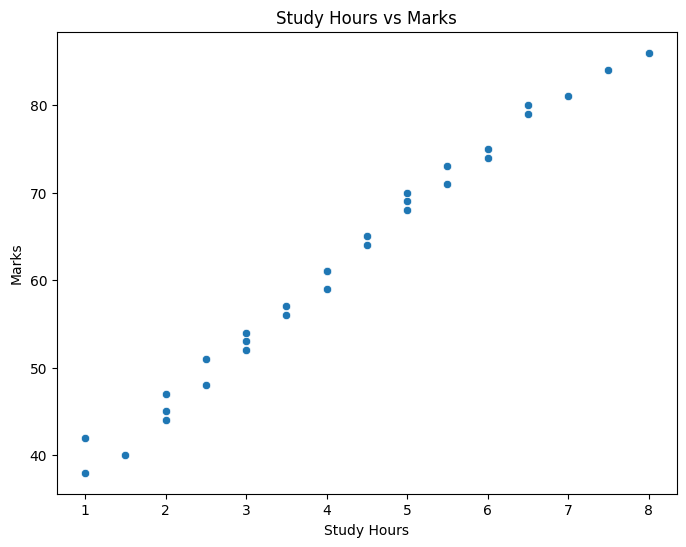

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Study_Hours', y='Marks', data=df)
plt.title('Study Hours vs Marks')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.show()



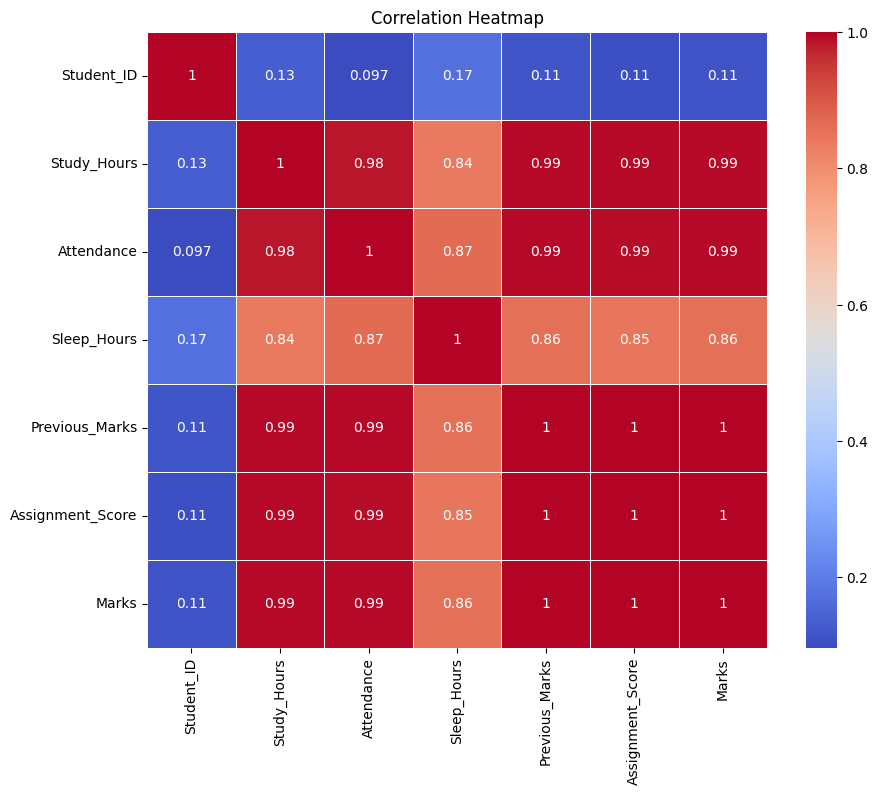

In [34]:
correlation  = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()



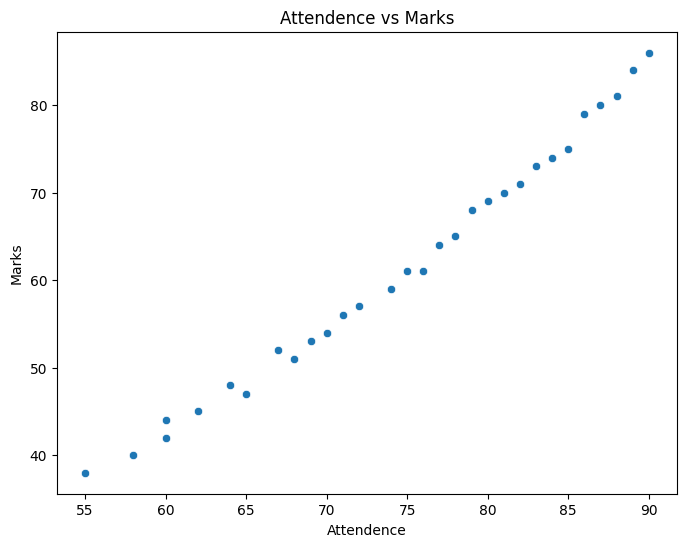

In [39]:
# Attendence improve marks ?
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Attendance'], y=df['Marks'] , data=df)
plt.title('Attendence vs Marks')
plt.xlabel('Attendence')
plt.ylabel('Marks')
plt.show()

In [40]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Sleep_Hours',
       'Previous_Marks', 'Assignment_Score', 'Marks'],
      dtype='object')

Machine Learning Model

In [42]:
X = df[['Study_Hours', 'Attendance' , 'Sleep_Hours',  'Previous_Marks', 'Assignment_Score']]

In [44]:
Y  = df['Marks']

In [46]:
#Split Data
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [48]:
# Train Model
model = sklearn.linear_model.LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
y_pred = model.predict(X_test)


In [52]:
# Accuracy
score = model.score(X_test, Y_test)
print("Model Accuracy:", score)

Model Accuracy: 0.9974534065591804


In [55]:
#Predict Student marks
student = pd.DataFrame({
    'Study_Hours': [5],
    'Attendance': [80],
    'Sleep_Hours': [7],
    'Previous_Marks': [85],
    'Assignment_Score': [90]
})

In [57]:
predication = model.predict(student)

In [58]:
print("Predicted Marks for the student:", predication[0])   

Predicted Marks for the student: 85.1767141812336
